# 最終課題: オリジナルAIの構築

このノートブックでは、自由にテーマを選んでオリジナルのAI/機械学習モデルを構築します。

## 1. 目的

- 何を予測・分類・生成したいかを記述する
- 使用するデータとモデルの種類を決める

## 2. 事前準備

必要なライブラリをここに追加します。

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('準備完了')

準備完了


## 3. データの読み込み

ここでデータを読み込んで、内容を確認します。

In [ ]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,112.4,32.1,10.3,17.46
1,285.2,4.2,90.3,20.35
2,219.6,8.1,50.5,18.76
3,179.6,44.9,82.6,22.89
4,46.8,30.3,32.0,14.36


## 4. 前処理

特徴量エンジニアリングやデータ整形を行います。

In [12]:
# 欠損値の確認
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [14]:
# 特徴量(X)とターゲット(y)に分割
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 学習用とテスト用に分割
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'学習データ: {X_train.shape}, テストデータ: {X_test.shape}')

学習データ: (160, 3), テストデータ: (40, 3)


In [15]:
# 例: データを学習に使いやすい形へ整形します
# 既存のサンプルデータを使用
X = sample_df[['feature_1', 'feature_2']]
y = sample_df['label']

# 特徴量の標準化
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 整形後の特徴量を確認
pd.DataFrame(X_scaled, columns=['feature_1_scaled', 'feature_2_scaled']).head()

,feature_1_scaled,feature_2_scaled
0,-1.414214,1.414214
1,-0.707107,0.707107
2,0.000000,0.000000
3,0.707107,-0.707107
4,1.414214,-1.414214


## 5. モデル構築

ここにモデルを作成します。

In [16]:
from sklearn.linear_model import LinearRegression

# 線形回帰モデルを作成
model = LinearRegression()

# 学習データでモデルを学習
model.fit(X_train, y_train)

# 学習した係数を確認
for feature, coef in zip(X.columns, model.coef_):
    print(f'{feature}: {coef:.4f}')
print(f'切片: {model.intercept_:.4f}')

feature_1: 0.0443
feature_2: 0.1841
切片: 6.8653


## 6. 学習と評価

モデルを学習させて、評価指標を確認します。

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# テストデータで予測
y_pred = model.predict(X_test)

# 評価指標を計算
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE  (平均絶対誤差): {mae:.3f}')
print(f'RMSE (二乗平均平方根誤差): {rmse:.3f}')
print(f'R2スコア (決定係数): {r2:.3f}')

MAE  (平均絶対誤差): 1.060
RMSE (二乗平均平方根誤差): 1.248
R2スコア (決定係数): 0.935


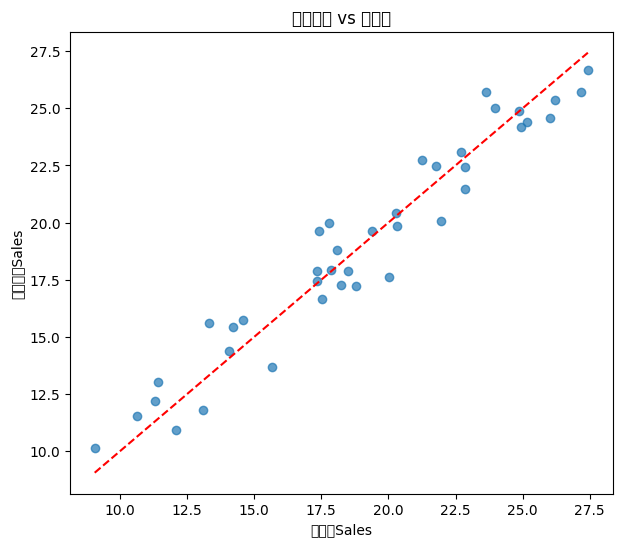

In [19]:
# 予測結果と実際の値を散布図で比較
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('実際のSales')
plt.ylabel('予測したSales')
plt.title('実際の値 vs 予測値')
plt.show()


In [23]:
# 各広告媒体がSalesにどれだけ影響しているか可視化
feature_names = X_train.columns.tolist()
coef_df = pd.DataFrame({
    '広告媒体': feature_names,
    '係数': model.coef_
}).sort_values('係数', ascending=False)


## 7. まとめ

- どんな結果が得られたか
- 今後改善したい点

線形回帰モデルを構築した結果、R2スコアは0.935となった。これは、モデルが売上の変動の約93.5%を広告費（TV・Radio・Newspaper）で説明できていることを意味し、当てはまりの非常に良いモデルであると言える。
広告媒体ごとの係数を見ると、Radio（係数0.184）が最も大きく、次いでTV（係数0.044）、Newspaper（係数0.016）の順となった。これは「Radio広告費を1単位増やすと売上が最も大きく伸びる」ことを示しており、3つの媒体の中ではRadioが売上への影響度が最も高いという結果になった。一方でNewspaperの係数は最も小さく、売上への影響は限定的であることが分かった。
散布図（実際の値 vs 予測値）では、多くの点が理想的な直線（y=xの赤い破線）の近くに分布しており、予測値と実際の値が概ね一致していることが視覚的にも確認できた。これはR2スコアが高かったこととも一致する結果である。
今後改善したい点

多項式回帰や正則化（Ridge・Lasso）を試して、線形回帰との精度を比較する
広告費同士の相互作用（TV×Radioなど）を新たな特徴量として追加し、モデルの表現力を高める
今回はサンプルデータを使用したため、実際の企業の広告データを用いて同様の分析を行い、現実のビジネスでも有効なモデルかを検証する